In [8]:
import jax
import gymnax

key = jax.random.key(0)
key, key_reset, key_act, key_step = jax.random.split(key, 4)

# Instantiate the environment & its settings.
env, env_params = gymnax.make("CartPole-v1")

# Reset the environment.
obs, state = env.reset(key_reset, env_params)

# Sample a random action.
action = env.action_space(env_params).sample(key_act)

# Perform the step transition.
n_obs, n_state, reward, done, _ = env.step(key_step, state, action, env_params)

/home/ronedr/.local/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


In [1]:
import jax
print(jax.devices())

ERROR:2025-10-11 23:02:18,284:jax._src.xla_bridge:626: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda13.initialize()
Traceback (most recent call last):
  File "/home/ronedr/.local/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 624, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/ronedr/.local/lib/python3.11/site-packages/jax_plugins/xla_cuda13/__init__.py", line 334, in initialize
    c_api = xb.register_plugin(
            ^^^^^^^^^^^^^^^^^^^
  File "/home/ronedr/.local/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 723, in register_plugin
    c_api = xla_client.load_pjrt_plugin_dynamically(plugin_name, library_path)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ronedr/.local/lib/python3.11/site-packages/jaxlib/xla_client.py", line 165, in load_pjrt_plugin_dynamically
    return _xla.load_pjrt_plugin(plugin_name, library_path, c_api=None)
           ^^^^^^^^^^^^^^^

[CudaDevice(id=0)]


E1011 23:02:18.455713 2593806 cuda_dnn.cc:534] Could not create cudnn handle: CUDNN_STATUS_NOT_INITIALIZED
E1011 23:02:18.455747 2593806 cuda_dnn.cc:538] Memory usage: 11558846464 bytes free, 11707809792 bytes total.
E1011 23:02:18.455787 2593806 cuda_dnn.cc:548] Possibly insufficient driver version: 555.42.6
E1011 23:02:18.456609 2593806 cuda_dnn.cc:534] Could not create cudnn handle: CUDNN_STATUS_NOT_INITIALIZED
E1011 23:02:18.456636 2593806 cuda_dnn.cc:538] Memory usage: 11558846464 bytes free, 11707809792 bytes total.
E1011 23:02:18.456655 2593806 cuda_dnn.cc:548] Possibly insufficient driver version: 555.42.6


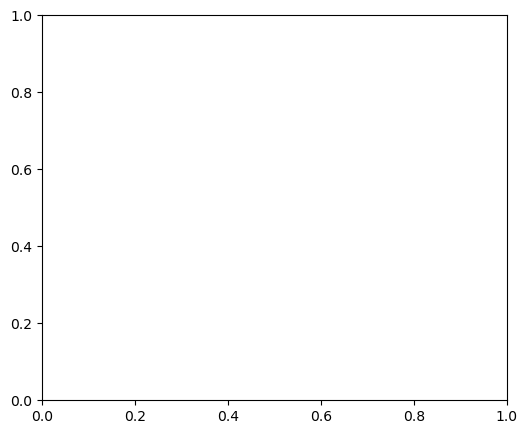

In [10]:
from gymnax.visualize import Visualizer
import jax.numpy as jnp

state_seq, reward_seq = [], []
key, key_reset = jax.random.split(key)
obs, env_state = env.reset(key_reset, env_params)
while True:
    state_seq.append(env_state)
    key, key_act, key_step = jax.random.split(key, 3)
    action = env.action_space(env_params).sample(key_act)
    next_obs, next_env_state, reward, done, info = env.step(
        key_step, env_state, action, env_params
    )
    reward_seq.append(reward)
    if done:
        break
    else:
      obs = next_obs
      env_state = next_env_state

cum_rewards = jnp.cumsum(jnp.array(reward_seq))
vis = Visualizer(env, env_params, state_seq, cum_rewards)
# vis.animate(f"docs/anim.gif")

In [12]:
vis.animate("d.gif")

MovieWriter ffmpeg unavailable; using Pillow instead.


IndexError: list index out of range

In [4]:
pip uninstall -y jax-cuda13-plugin jax-cuda13-pjrt jax-cuda12-plugin jax-cuda12-pjrt

Found existing installation: jax-cuda13-pjrt 0.7.2
Uninstalling jax-cuda13-pjrt-0.7.2:
  Successfully uninstalled jax-cuda13-pjrt-0.7.2
ERROR: Exception:
Traceback (most recent call last):
  File "/storage/modules/packages/anaconda/lib/python3.11/site-packages/pip/_internal/cli/base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/storage/modules/packages/anaconda/lib/python3.11/site-packages/pip/_internal/commands/uninstall.py", line 110, in run
    uninstall_pathset.commit()
  File "/storage/modules/packages/anaconda/lib/python3.11/site-packages/pip/_internal/req/req_uninstall.py", line 432, in commit
    self._moved_paths.commit()
  File "/storage/modules/packages/anaconda/lib/python3.11/site-packages/pip/_internal/req/req_uninstall.py", line 278, in commit
    save_dir.cleanup()
  File "/storage/modules/packages/anaconda/lib/python3.11/site-packages/pip/_internal/utils/temp_dir.py", line 173, in cleanup
    rmtree(self

In [3]:
pip uninstall -y jax jaxlib

Found existing installation: jax 0.5.1
Uninstalling jax-0.5.1:
  Successfully uninstalled jax-0.5.1
Found existing installation: jaxlib 0.5.1
Uninstalling jaxlib-0.5.1:
  Successfully uninstalled jaxlib-0.5.1
ERROR: Exception:
Traceback (most recent call last):
  File "/storage/modules/packages/anaconda/lib/python3.11/site-packages/pip/_internal/cli/base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/storage/modules/packages/anaconda/lib/python3.11/site-packages/pip/_internal/commands/uninstall.py", line 110, in run
    uninstall_pathset.commit()
  File "/storage/modules/packages/anaconda/lib/python3.11/site-packages/pip/_internal/req/req_uninstall.py", line 432, in commit
    self._moved_paths.commit()
  File "/storage/modules/packages/anaconda/lib/python3.11/site-packages/pip/_internal/req/req_uninstall.py", line 278, in commit
    save_dir.cleanup()
  File "/storage/modules/packages/anaconda/lib/python3.11/site-packag